In [3]:
# import lanfactory
# import torch
# Import necessary packages
import numpy as np
import pandas as pd
import ssms
from ssms.basic_simulators.simulator import simulator
import hssm
from hssm.distribution_utils.onnx import onnx as onx
import bambi as bmb
import matplotlib.pyplot as plt
import pickle
from functools import partial
from copy import deepcopy

In [4]:
MODEL = 'par'

In [6]:
#load in a model
if MODEL == 'seq':
    network_config = '/users/avo2/hddm/hddm/torch_models/247aa76015d311ec922d3cecef057012_seq2_no_bias_torch__network_config.pickle'
    network_file_path = '/users/avo2/hddm/hddm/torch_models/247aa76015d311ec922d3cecef057012_seq2_no_bias_torch_state_dict.pt'
    model_name = 'ddm_seq2_no_bias'
elif MODEL == 'par':  
    network_config = '/users/avo2/hddm/hddm/torch_models/495136c615d311ecb5fda0423f39a3e6_par2_no_bias_torch__network_config.pickle'
    network_file_path = '/users/avo2/hddm/hddm/torch_models/495136c615d311ecb5fda0423f39a3e6_par2_no_bias_torch_state_dict.pt'
    model_name = 'ddm_par2_no_bias'
elif MODEL == 'leak':
    network_config = '/users/avo2/data/avo2/LANminimal/data/networks/torch/lan/mic2_small/mic2_small_lan_ff18042ef20011eea389ac1f6bfea5a4_train_config.pickle'
    network_file_path = '/users/avo2/data/avo2/LANminimal/data/networks/torch/lan/mic2_small/mic2_small_lan_ff18042ef20011eea389ac1f6bfea5a4_train_state_dict_torch.pt'
    model_name = 'ddm_mic2_leak_no_bias_no_lowdim_noise'

config = deepcopy(ssms.config.model_config[model_name])

config_list = config['params']
input_dim = len(config['params'])
# network = lanfactory.trainers.LoadTorchMLPInfer(model_file_path = network_file_path,
#                                                 network_config = network_config,
#                                                 input_dim = input_dim + 2)

In [7]:

with open(network_config, 'rb') as handle:
    b = pickle.load(handle)

In [7]:
b

{'layer_types': ['dense', 'dense', 'dense', 'dense'],
 'layer_sizes': [100, 100, 100, 1],
 'activations': ['tanh', 'tanh', 'tanh', 'linear'],
 'loss': ['huber'],
 'callbacks': ['checkpoint', 'earlystopping', 'reducelr'],
 'model_id': 'seq2_no_bias'}

106
293
9503
98


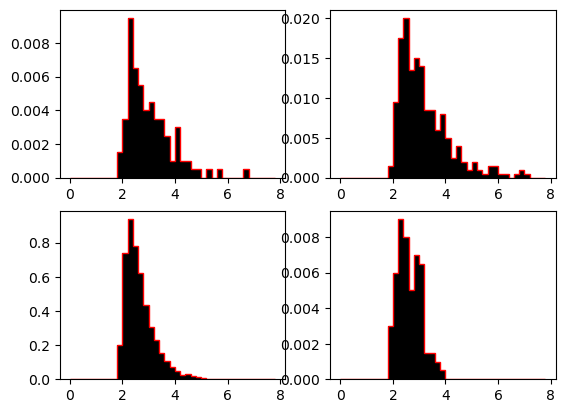

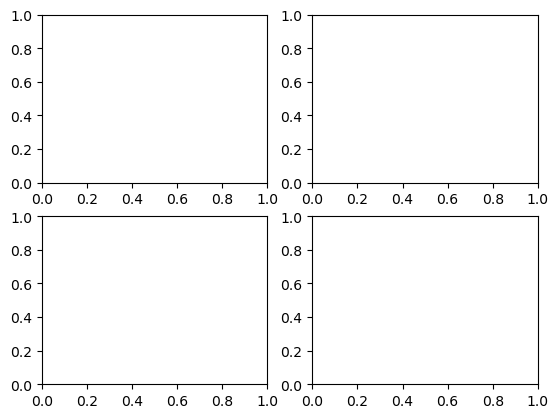

1676
8121
203
0


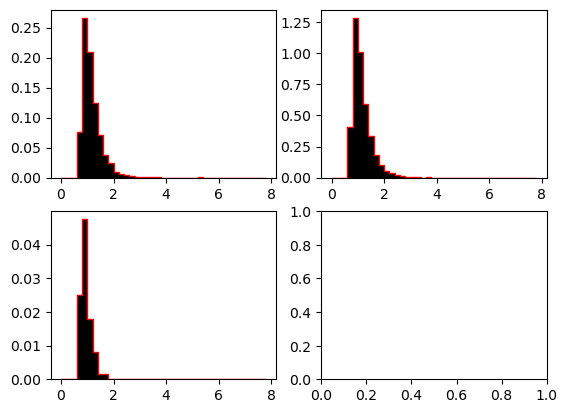

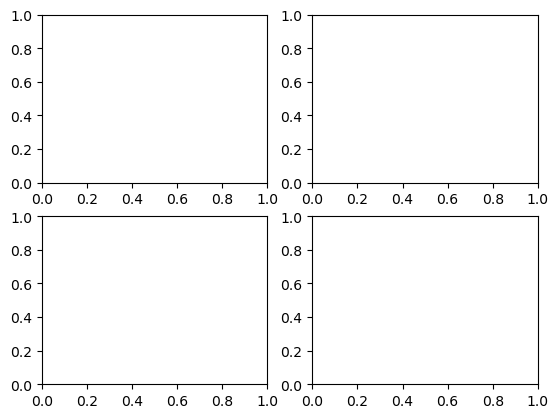

1
9980
19
0


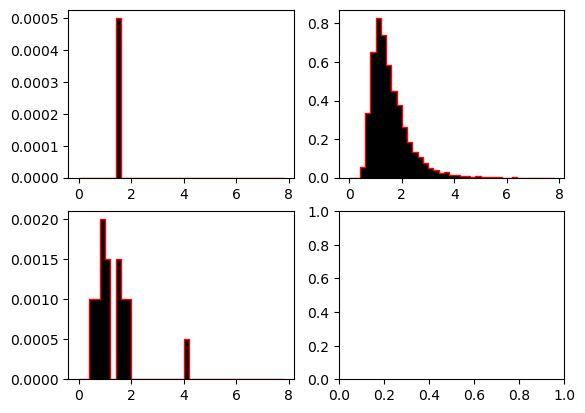

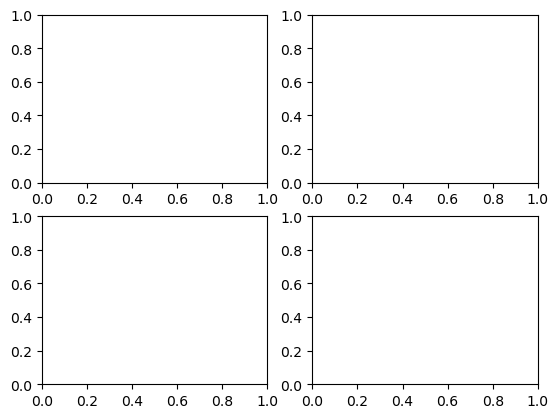

0
6
13
9981


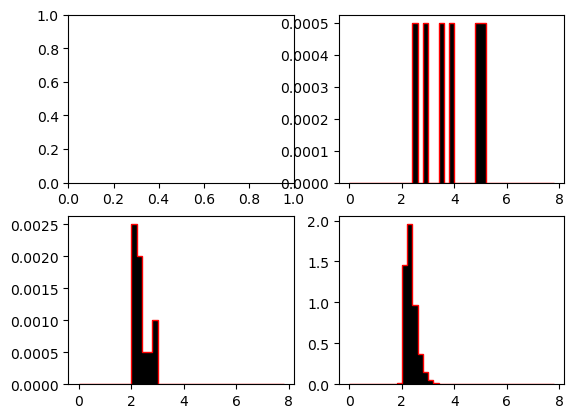

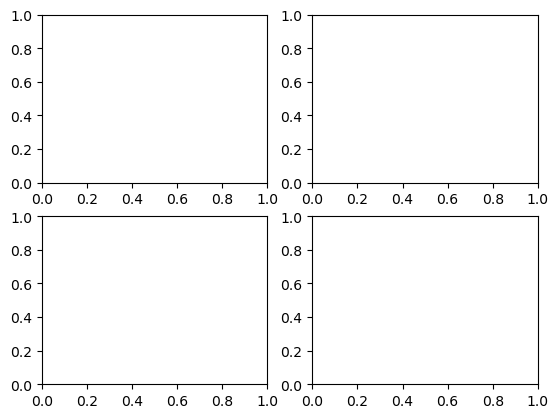

In [19]:
dataset_size = 10000

for loop in range(4):
    #make some data
    config = deepcopy(ssms.config.model_config[model_name])

    config_list = config['params']

    param_dict = {}
    for i in range(len(config_list)):
        #Draw a random unif (low,high), then add to dictionary
        param_dict[config_list[i]] = np.random.uniform(config['param_bounds'][0][i], config['param_bounds'][1][i])


    obs_lca = simulator(
            param_dict, model=model_name, n_samples=dataset_size, smooth_unif = False, delta_t = 0.005
                )

    #New delta t
    obs_lca2 = simulator(
        param_dict, model=model_name, n_samples=dataset_size, smooth_unif = False, delta_t = 0.005
            )
            #Turn into legible data
    dataset_lca =  np.column_stack([obs_lca["rts"][:, 0], obs_lca["choices"][:, 0]])
    dataset_lca = dataset_lca.astype(float)
    dataset_lca2 =  np.column_stack([obs_lca2["rts"][:, 0], obs_lca2["choices"][:, 0]])
    dataset_lca2 = dataset_lca2.astype(float)

    param_array = []
    for k in param_dict.keys():
        param_array.append(param_dict[k])

    param_full = np.repeat(np.array(param_array).reshape((1,input_dim)), dataset_size, axis = 0)
    reaction_times = np.linspace(0, 8, dataset_size).reshape((dataset_size,1))
    # choices = np.random.choice([0,1,2,3], size = dataset_size).reshape((dataset_size,1))
    # final_output = torch.from_numpy(np.concatenate((param_full, reaction_times, choices), axis = 1, dtype = np.float32)).to('cuda:0')
    # network_output = network(final_output)


    #Select each choices
    fig, ax = plt.subplots(2,2)


    fig2, ax2 = plt.subplots(2,2)
    


    my_bins = np.arange(0,8,0.2) 
    bin_length = np.abs((my_bins[1] - my_bins[0]))


    for i in range(4):
        
        # param_full = np.repeat(np.array(param_array).reshape((1,input_dim)), dataset_size, axis = 0)
        # reaction_times = np.linspace(0, 8, dataset_size).reshape((dataset_size,1))
        # choices = np.repeat((np.array([i])), dataset_size).reshape((dataset_size,1))
        # final_output = torch.from_numpy(np.concatenate((param_full, reaction_times, choices), axis = 1, dtype = np.float32)).to('cuda:0')
        # network_output = network(final_output)
        # likelihoods = np.exp(network_output.cpu())
        GT_array = dataset_lca[dataset_lca[:,1] == i][:,0]
        GT_array2 = dataset_lca2[dataset_lca2[:,1] == i][:,0]
        # ax[i//2,i%2].plot(reaction_times, likelihoods)
        # ax2[i//2,i%2].plot(reaction_times, likelihoods)
        # ax2[i//2,i%2].set_ylim([0, 1])
    #% of that choice in the dataset
        gt_shape = GT_array.shape[0]
        print(gt_shape)
        gt_shape2 = GT_array2.shape[0]
        if gt_shape != 0:
            density_ratio = gt_shape /dataset_size
            density_ratio2 = gt_shape2 /dataset_size
            weights = np.repeat((density_ratio/(gt_shape )/bin_length), gt_shape )
            ax[i//2,i%2].hist(GT_array, bins = my_bins, density = False, weights = np.repeat((density_ratio/gt_shape/bin_length), gt_shape), color = 'black')
            ax[i//2,i%2].hist(GT_array, bins = my_bins, density = False, weights = np.repeat(1/(dataset_size*bin_length), gt_shape), histtype='step', color = 'red')
            # ax2[i//2,i%2].hist(GT_array, bins = my_bins, density = False, weights = np.repeat((density_ratio/gt_shape/bin_length), gt_shape), histtype='step')
            # ax2[i//2,i%2].hist(GT_array2, bins = my_bins, density = False, weights = np.repeat((density_ratio2/gt_shape2/bin_length), gt_shape2), histtype='step') 
    
    plt.show()

In [18]:
help(simulator)

Help on function simulator in module ssms.basic_simulators.simulator:

simulator(theta, model='angle', n_samples=1000, delta_t=0.001, max_t=20, no_noise=False, bin_dim=None, bin_pointwise=False, smooth_unif=True, return_option='full', random_state=None)
    Basic data simulator for the models included in HDDM.
    
    Arguments
    ---------
        theta : list, numpy.array, dict or pd.DataFrame
            Parameters of the simulator. If 2d array, each row is treated as a 'trial'
            and the function runs n_sample * n_trials simulations.
        deadline : numpy.array <default=None>
            If supplied, the simulator will run a deadline model. RTs will be returned
        model: str <default='angle'>
            Determines the model that will be simulated.
        n_samples: int <default=1000>
            Number of simulation runs for each row in the theta argument.
        delta_t: float
            Size fo timesteps in simulator (conceptually measured in seconds)
     

In [41]:
param_array

[-0.33600664159360694,
 -3.9589055714414334,
 3.509065404426501,
 0.5619589679730248,
 1.7830447537986778]

In [43]:
np.exp(final_output[np.where(choices == i)[0]].cpu())

tensor([], size=(0, 7))

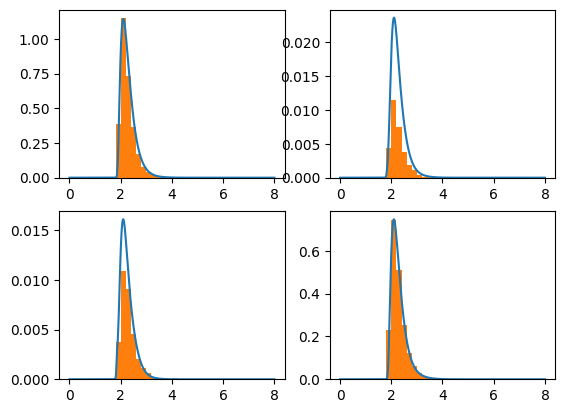

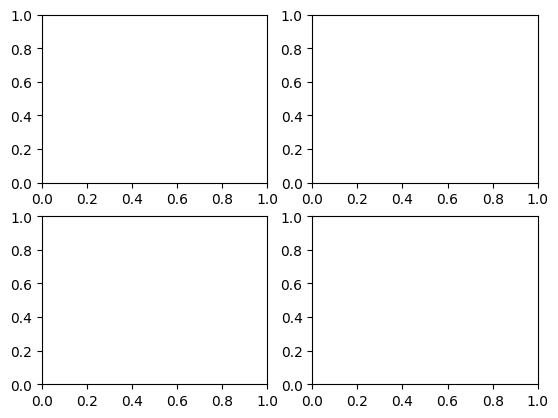

In [193]:
dataset_lca[dataset_lca[:,1] == 1][:,0]

array([3.37141228, 3.04939747, 3.70442796, 2.68738818, 2.60138941,
       2.36639237, 3.68342686, 4.77736378, 2.72438765, 2.41939163,
       3.47441721, 2.50239062, 2.41439176, 2.91239095, 2.86838889,
       3.15340233, 2.73738766, 3.38741302, 2.51839042, 2.30939293,
       2.9493928 , 2.89439011, 2.95039272, 3.10739994, 4.22440386,
       3.19240403, 2.45739126, 2.99539471, 2.85838842, 3.41141415,
       2.5723896 , 3.384413  , 2.48039079, 2.26839352, 2.94739246,
       4.88635588, 2.81838655, 2.49339056, 2.47239089, 3.43541527,
       2.76638722, 3.41441441, 3.51841927, 2.61838913, 2.3243928 ,
       3.30140924, 3.53041983, 2.34139252, 2.69138813, 3.64242506,
       2.51839042, 2.71638775, 2.85838842, 2.2573936 , 2.31139302,
       2.72538757, 3.07039833, 4.15740871, 3.13840151, 2.64938879,
       2.89439011, 2.78238702, 2.54438996, 2.62838888, 2.95139265,
       3.65942574, 3.21940517, 2.5583899 , 2.49439073, 2.72338772,
       2.61138916, 2.42239165, 3.28940868, 3.69442749, 3.70042

In [191]:
dataset_lca[:,1]

array([2., 2., 2., ..., 2., 2., 2.])

In [100]:
param_array = []
for k in param_dict.keys():
    param_array.append(param_dict[k])



In [74]:
np.unique(dataset_lca['response'])

array([0., 1.])

In [9]:
class ModelPipeline:
    """
    This class is used to generate data based on parameters, fit and graph with HSSM and arviz. Supports 'freezing' certain parameters as scalars.

    Attributes
    -----------
        model_name: str
        model_config: dict

    Methods
    ----------

    Returns
    ----------
    """

    def __init__(self, path_to_onnx, model_name):
        self.path_to_onnx = path_to_onnx
        self.model_name = model_name
        self.model_config = deepcopy(ssms.config.model_config[self.model_name])
        # if model_name == 'ddm_mic2_leak_no_bias_no_lowdim_noise':
        #     self.model_config['params'] = self.model_config['params'][:-1] #currently there's an extra p_outlier param at the end, so we are cutting that out
    def parameter_randomiser(self, set_value_dict = None):
        '''
        Function that generates the relevant parameters to feed to release_params
            set_value_dict: dict
                a dictionary of {name, set value} for any parameters you want to fix


    Return:
      parameter_dict: a dictionary of the parameters

    '''

        #Get the parameter list from ssms
        config = self.model_config
        config_list = config['params']

        param_dict = {}
        for i in range(len(config_list)):
            #Draw a random unif (low,high), then add to dictionary
            param_dict[config_list[i]] = np.random.uniform(config['param_bounds'][0][i], config['param_bounds'][1][i])
        
        #Update the param_dict with set values in the set_value_dict
        if set_value_dict != None:
            for i in set_value_dict.keys():
                param_dict[i] = set_dict[i]

        self.param_dict=param_dict
        return self.param_dict
    
    def dataset_generator(self, fixed_int = [], fixed_coh = [], dataset_size=1000):

        obs_lca = simulator(
        self.param_dict, model=self.model_name, n_samples=dataset_size, smooth_unif = False
            )
        #Turn into legible data
        dataset_lca = pd.DataFrame(
        np.column_stack([obs_lca["rts"][:, 0], obs_lca["choices"][:, 0]]),

        columns=["rt", "response"],
        )
        dataset_lca = dataset_lca.astype(float)

        if not hasattr(self, 'dataset'):
            self.dataset=dataset_lca

        return dataset_lca

    def partial_hssm(self, freeze=[]):
        
    #Generate the right bound format to feed into HSSM    
        def config_generator():
            '''
            Utils function that transforms the model_config from SSMS output to HSSM

            Returns
            -------
            config_dict: dict
                        
            '''
            bound_dict = {}
            for i in range(self.model_config['n_params']):
                bound_dict[self.model_config['params'][i]] = (self.model_config['param_bounds'][0][i], self.model_config['param_bounds'][1][i]) #tuple of low,high
            config_dict = {}
            config_dict['list_params'] = self.model_config['params']
            config_dict['bounds'] = bound_dict
            config_dict['backend'] = 'pytensor'

            return config_dict
        
        # include_builder = []
        # if freeze.count('vl1') == 0:
        #     include_builder.append({
        #             "name": "vl1",
        #             "prior": {
        #                 "intercept_vl1": {"name": "Uniform", "lower": -4.0, "upper": 4.0},
        #                 "y": {"name": "Normal", "mu": 0, "sigma": 1.0}
        #             },
        #             "formula": "vl1 ~ 1 + y",
        #             "link": "identity",
        #             })
        
        # if freeze.count('vh') == 0:
        #     include_builder.append({
        #         "name": "vh",
        #         "prior": {
        #             "intercept_vh": {"name": "Uniform", "lower": -4.0, "upper": 4.0},
        #             "x": {"name": "Normal", "mu": 0, "sigma": 1.0},
        #         },
        #         "formula": "vh ~ 1 + x",
        #         "link": "identity",
        #         })
    #Create the original partial function, note that calling hssm.HSSM(v=2.5), for example, will set v=2.5 in the final model.
        partial_hssm = partial(hssm.HSSM,
        data=self.dataset,
        model= self.model_name,
        p_outlier=0.0,
        loglik=self.path_to_onnx,
        loglik_kind="approx_differentiable",
        model_config=config_generator(),
        )

        #Generate the dictionary to feed into the partial function by going through freeze and creating a {param,value} dict
        freezeDict = {}
        for i in freeze:
            if i in self.param_dict.keys():
                freezeDict.update({i: self.param_dict[i]})

        #Create HSSM model
        partial_model = partial_hssm(**freezeDict)
        self.hssm_model = partial_model

        return partial_model

    def run(self, freeze = []):
        self.parameter_randomiser()
        self.dataset_generator()
        self.hssm_model = self.partial_hssm(freeze = freeze)
        print(self.model_config)
        return self.hssm_model

    def sample(self, sampler = 'nuts_numpyro', chains=2, cores=1, draws=1000, tune=500):
    #Sample
        output = self.hssm_model.sample(sampler = sampler ,init='jitter+adapt_diag', chains=chains, cores=cores, draws=draws, tune=tune)
        self.sample_output = output
        self.chains = chains
        self.draws = draws
        return output

    import math

    def posterior_predictive(self, size=1000 ):

        #Reconstruct the regression targets
        dataset_length = size
        mean_by_chain = self.sample_output.posterior.mean(dim='draw').drop_vars(['vl1', 'rt,response_obs']).to_dataframe()
        vh_reconstructed = np.zeros((dataset_length, self.chains))
        vl1_reconstructed = np.zeros((dataset_length,self.chains))
        regressor_x = np.random.uniform(-1, 1, size=size) 
        regressor_y = np.random.uniform(-1, 1, size=size)
        
        #reuse regressor, but repeat
        #instead of taking the posterior mean, take a sample from the posterior, then run a sim to get the RT choice

        #Loop through each chain to recreate regression targets based on mean by chains
        for i in range(self.chains):
            vh_reconstructed[:,i] = mean_by_chain['vh_Intercept'][i] + (mean_by_chain['vh_x'][i] * regressor_x)
            vl1_reconstructed[:,i] = mean_by_chain['vl1_Intercept'][i] +  (mean_by_chain['vl1_y'][i] * regressor_y)

        
        sim_output_list = [] #list of dictionaries
        
        #Loop through each chain to recreate the vector, then simulate with ssms to get posterior predictives.
        for c in range(self.chains):
            copydict = deepcopy(self.param_dict)
            for k in list(mean_by_chain.keys()): #If the param of the idata table matches the one in dict, we update it with the posterior mean
                if k in copydict:
                    copydict[k] = mean_by_chain[k][c]
            copydict.update({'vh': vh_reconstructed[:,c], 'vl1': vl1_reconstructed[:,c]}) #Then we update it with the regression targets
            # posterior_predictive_dict.append(copydict)
            

            obs_ppd = simulator(copydict, model= self.model_name, n_samples=1)
            dataset_obs = pd.DataFrame(
                            np.column_stack((obs_ppd["rts"][:, 0], obs_ppd["choices"][:, 0])),
                            columns=["rt", "response"])
            sim_output_list.append(dataset_obs)

           

        #calculate density of choices for plot
        groundtruth_ppd = self.dataset_generator(size)
        choice_p_ppd = np.zeros((4,self.chains))
        choice_p_gt = np.zeros(4)

        for i in range(4):
            choice_p_gt[i] = int(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            print(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            for c in range(self.chains):
                choice_p_ppd[i][c] = int(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'].shape[0])
        density_ratio_ppd = choice_p_ppd/size
        density_ratio_gt = choice_p_gt/size
        print(choice_p_ppd)
        print(choice_p_gt)
        print(density_ratio_ppd)
        print(density_ratio_gt)
        #plot


        
        my_bins = np.arange(0,12,0.2) 
        bin_length = np.abs((my_bins[1] - my_bins[0]))


        for c in range (self.chains): #Loop through chains
            fig,ax = plt.subplots(2, 2)
            for i in range(4): #Loop through choices
                ax[i//2,i%2].hist(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'],
                                  bins=my_bins, alpha = 0.5, color = 'red', density = False,
                                  weights = np.repeat(density_ratio_ppd[i][c]/choice_p_ppd[i][c]/bin_length, choice_p_ppd[i][c]))
                ax[i//2,i%2].hist(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'],
                                  bins=my_bins, alpha = 0.5, density = False,
                                  weights=np.repeat(density_ratio_gt[i]/choice_p_gt[i]/bin_length, choice_p_gt[i]))
        return sim_output_list

    def show_ground_truth(self):
        groundtruthDict = {}
        for i in self.param_dict.keys():
            if isinstance(self.param_dict[i], float):
                groundtruthDict[i] = self.param_dict[i]

        for i in self.regressor_groundtruth.keys():
            if isinstance(self.regressor_groundtruth[i], float):
                groundtruthDict[i] = self.regressor_groundtruth[i]

        self.groundtruthDict = groundtruthDict

        posterior_mean = self.sample_output.posterior.mean().to_pandas().to_dict()

        compareDict = {}
        for k in groundtruthDict.keys():
            if k in posterior_mean:
                compareDict[k] = (groundtruthDict[k], posterior_mean[k])
            else:
                compareDict[k] = groundtruthDict[k]
        self.compareDict = compareDict
        return compareDict

    
    def posterior_predictive_copy(self, size):
        '''

        Inputs
        ------
        size: int
              the number of times of the dataset to call for posterior predictive. This is relevant because we are re-using regressors from the ground truth.
        '''
    
        #Reconstruct the regression targets by repeating them, note 
        dataset_length = size
        mean_by_chain = self.sample_output.posterior.mean(dim='draw').drop_vars(['vl1', 'rt,response_obs']).to_dataframe()
        vh_reconstructed = np.zeros((self.draws * size, self.chains))
        vl1_reconstructed = np.zeros((self.draws * size ,self.chains))
        regX_repeated = np.repeat(self.regressor_groundtruth['regressor_x'], size)
        regY_repeated = np.repeat(self.regressor_groundtruth['regressor_y'], size)
        df = self.sample_output.posterior.drop_vars(['rt,response_obs', 'vl1']).to_dataframe() #process the trace object
        #Loop through each chain to recreate regression targets based on mean by chains
        for c in range(self.chains):
            vh_reconstructed[:,c] = df['vh_Intercept'][c] + df['vh_x'][c] * regX_repeated
            vl1_reconstructed[:,c] = df['vl1_Intercept'][c] + df['vl1_y'][c] * regY_repeated

        sim_output_list = [] #list of dictionaries
        
        #Loop through each chain to recreate the vector, then simulate with ssms to get posterior predictives.
        for c in range(self.chains):
            copydict = deepcopy(self.param_dict)
            for k in list(df.keys()): #If the param of the idata table matches the one in dict, we update it with the trace
                if k in copydict:
                    copydict[k] = df[k][c].to_numpy()
            copydict.update({'vh': vh_reconstructed[:,c], 'vl1': vl1_reconstructed[:,c]}) #Then we update it with the regression target
            #Simulate and organise into rt, choices
            obs_ppd = simulator(copydict, model= self.model_name, n_samples=1, smooth_unif = False)
            dataset_obs = pd.DataFrame(
                            np.column_stack((obs_ppd["rts"][:, 0], obs_ppd["choices"][:, 0])),
                            columns=["rt", "response"])
            sim_output_list.append(dataset_obs)

            

        #PLOTTING
        
        #calculate density of choices for plot
        groundtruth_ppd = self.dataset_generator(fixed_coh = self.fixed_coh, dataset_size = self.draws * size)
        choice_p_ppd = np.zeros((4,self.chains))
        choice_p_gt = np.zeros(4)

        for i in range(4):
            choice_p_gt[i] = int(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            print(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            for c in range(self.chains):
                choice_p_ppd[i][c] = int(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'].shape[0])
        density_ratio_ppd = choice_p_ppd/size
        density_ratio_gt = choice_p_gt/size
        #plot


        
        my_bins = np.arange(0,12,0.2) 
        bin_length = np.abs((my_bins[1] - my_bins[0]))
        
        plotting_dict = {'choice_ppd': choice_p_ppd,
                         'choice_p_gt': choice_p_gt,
                         'sim_output_list': sim_output_list,
                         'groundtruth_ppd': groundtruth_ppd}

        for c in range (self.chains): #Loop through chains
            fig,ax = plt.subplots(2, 2)
            for i in range(4): #Loop through choices
                ax[i//2,i%2].hist(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'],
                                    bins=my_bins, alpha = 0.5, color = 'red', density = False,
                                    weights = np.repeat(density_ratio_ppd[i][c]/choice_p_ppd[i][c]/bin_length, choice_p_ppd[i][c]))
                ax[i//2,i%2].hist(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'],
                                    bins=my_bins, alpha = 0.5, density = False,
                                    weights=np.repeat(density_ratio_gt[i]/choice_p_gt[i]/bin_length, choice_p_gt[i]))
        
        self.plotting_dict = plotting_dict
        
        return plotting_dict

    def save(self, path, file_name):
        '''
        Pickle the trace, parameter dictionary as well as the arrays to use for posterior predictive plotting
        '''
        save_dict = {
            'trace': self.sample_output,
            'params': self.param_dict,
            'plot_dict': self.plotting_dict,
            'compareDict': self.compareDict
        }

        with open(path + file_name + '.pickle', 'wb') as handle:
            pickle.dump(save_dict, handle)

        
        return 

        


In [10]:
MODEL_NAME = 'seq'
if MODEL_NAME == 'seq':
    model_onnx_path = '/users/avo2/data/avo2/tsumme_data/seq2_no_bias'
    model_name = 'ddm_seq2_no_bias'
elif MODEL_NAME == 'par':
    model_onnx_path = '/users/avo2/data/avo2/tsumme_data/par2_no_bias'
    model_name = 'ddm_par2_no_bias'
elif MODEL_NAME == 'leak':
    model_onnx_path = '/users/avo2/data/avo2/LANminimal/data/networks/torch/lan/mic2_small/mic2_small_lan_ff18042ef20011eea389ac1f6bfea5a4_train_config.pickle'
# model_onnx_path = '/users/avo2/data/avo2/tsumme_data/seq2_no_bias'
    model_name = 'ddm_mic2_leak_no_bias_no_lowdim_noise'
# model_name = 'ddm_seq2_no_bias'
modelPipe =  ModelPipeline(model_name= model_name,
                           path_to_onnx = model_onnx_path)

modelPipe.parameter_randomiser()
modelPipe.dataset_generator()
modelPipe.partial_hssm(freeze = ['d', 'a','t'])

You have specified the `lapse` argument to include a lapse distribution, but `p_outlier` is set to either 0 or None. Your lapse distribution will be ignored.


Hierarchical Sequential Sampling Model
Model: ddm_seq2_no_bias

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 1000

Parameters:

vh:
    Prior: Uniform(lower: -4.0, upper: 4.0)
    Explicit bounds: (-4.0, 4.0)

vl1:
    Prior: Uniform(lower: -4.0, upper: 4.0)
    Explicit bounds: (-4.0, 4.0)

vl2:
    Prior: Uniform(lower: -4.0, upper: 4.0)
    Explicit bounds: (-4.0, 4.0)

a:
    Prior: 0.8170476674590743
    Explicit bounds: (0.3, 2.5)

t:
    Prior: 0.6448410370906952
    Explicit bounds: (0.0, 2.0)

In [33]:
modelPipe.dataset

,rt,response
0,1.255837,1.0
1,1.374835,0.0
2,1.121838,1.0
3,1.593832,1.0
4,1.114838,0.0
...,...,...
995,0.965840,1.0
996,1.367835,1.0
997,0.998840,1.0
998,1.114838,1.0


In [36]:
modelPipe.hssm_model.pymc_model.logp({'vl2_interval__': 3, 'vl1_interval__': 2, 'vh_interval__': 1})

TypeError: unhashable type: 'dict'

In [25]:
model = modelPipe.hssm_model.pymc_model

In [26]:
model.test_point

AttributeError: 'Model' object has no attribute 'test_point'